In [1]:
import os
import sys
import math
import random
import torch

sys.path.append("..")
from io import BytesIO
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import requests
import zarr
import matplotlib.pyplot as plt
from PIL import Image
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
from torch.utils.data import DataLoader

from utils.DataProcessing import MultimodalDataset
from utils.AstroImageFunctions import make_rgb
from models.MAE import MaskedAutoencoderViT

from utils.DataProcessing import (
    generate_rest_indices,
    get_extreme_mask,
    get_kernel,
    safe_collate,
    smooth_data,
    MultimodalDataset,
    CreateMultimodalDataLoadersIter,
)

/global/cfs/cdirs/desi/users/pzehao/envs/peng/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from models.MAESimple import MaskedAutoencoderViT
# path = "/pscratch/sd/p/pzehao/DESIMAE/ProductionCheckpointsFinal/epoch=005-val_loss=-1.0120.ckpt"
path = "/pscratch/sd/p/pzehao/DESIMAE/ProductionCheckpointsSimple/epoch=106-val_loss=-1.5629.ckpt"
# path = "/pscratch/sd/p/pzehao/DESIMAE/ImageMHP/epoch=225-val_loss=-2.3145.ckpt"


prob = 0.7/15

model = MaskedAutoencoderViT(spec_dim=7781,
        max_epochs=600,
        warmup_epoch=5,
        mask_ratio=0.75,
        embed_dim        = 256,
        merged_depth     = 4,
        merged_num_heads = 8,
        s_depth          = 4,
        e_depth          = 4,
        s_num_heads      = 8,
        e_num_heads      = 8,
        decoder_embed_dim= 512,
        decoder_depth    = 8,
        decoder_num_heads= 16,
        decoder_MLP_coefficient = 1,
        patch_scheme={
            "patch_sizes": [1, 1, 2, 4, 8, 16, 32, 64, 128, 64, 32, 16, 8, 4, 2, 1],
            "mask_ratios": [1, 0.9, 0.8, 0.75, 0.7, 0.65, 0.6, 0.55, 0.5, 0.45, 0.4, 0.35, 0.3, 0.2, 0.1, 0.0],
            "probs": [0.3, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob]
        })
# load model from checkpoint (non-strict for backward compatibility)
checkpoint = torch.load(path, map_location="cpu")
model.load_state_dict(checkpoint["state_dict"], strict=False)
model.eval()

/tmp/ipykernel_377730/3537586870.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location="cpu")


MaskedAutoencoderViT(
  (patch_embed1d): PatchEmbed1D(
    (proj): Conv1d(1, 256, kernel_size=(31,), stride=(31,))
    (norm): Identity()
  )
  (patch_embedimg): PatchEmbed(
    (proj): Conv2d(1, 256, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (s_attn): ModuleList(
    (0-3): 4 x Block(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=256, out_features=768, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=256, out_features=256, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=256, out_features=1024, bias=True)
        (act): GELU(approximate='none')
        (d

In [3]:
def visualize_unmasked_input(model, spec: torch.Tensor, error: torch.Tensor, spec_pred: torch.Tensor, 
                error_pred: torch.Tensor, img: torch.Tensor, pred_img: torch.Tensor, error_img: torch.Tensor, mask_spec: torch.Tensor, mask_img: torch.Tensor, xy_pix: torch.Tensor,
                i: int = 0, ylims: tuple = (-1, 20), xlims: tuple = (0, 8700), nsmooth: int = 3):
    kernel = get_kernel(nsmooth)

    # Extract relevant sample
    target = spec[i].detach().cpu().numpy()
    target_error = error[i].detach().cpu().numpy()
    pred_mean = spec_pred[i].detach().cpu().numpy()
    pred_sigma = np.exp(error_pred[i].detach().cpu().numpy())
    patch_mask_spec = mask_spec[i].detach().cpu()
    patch_mask_img = mask_img[i].detach().cpu()

    # Smooth signal and error
    target_smooth = smooth_data(target, kernel)
    target_error_smooth = smooth_data(target_error, kernel)
    pred_mean_smooth = smooth_data(pred_mean, kernel)
    pred_sigma_smooth = smooth_data(pred_sigma, kernel)

    # Compute intervals
    pred_upper = pred_mean_smooth + pred_sigma_smooth
    pred_lower = pred_mean_smooth - pred_sigma_smooth
    data_upper = target_smooth + target_error_smooth
    data_lower = target_smooth - target_error_smooth

    # Plot masked reconstruction
    fig, ax = plt.subplots(figsize=(10, 3))
    offset = model.left_patches * model.patch_size
    x_range = np.arange(offset, offset + len(target_smooth))
    ax.plot(x_range, target_smooth, label="Target (smoothed)", color="orange", linewidth=1)
    ax.fill_between(x_range, data_lower, data_upper, color="orange", alpha=0.3, label="±σ data (smoothed)")
    ax.plot(pred_mean_smooth, label="Prediction (smoothed)", color="blue")
    ax.fill_between(range(len(pred_mean_smooth)), pred_lower, pred_upper, color="blue", alpha=0.3, label="±σ predicted (smoothed)")
    patch_len = model.patch_size
    for j, masked in enumerate(patch_mask_spec):
        if masked:
            start = offset + j * patch_len
            end = offset + (j + 1) * patch_len
            ax.axvspan(start, end, color='red', alpha=0.05)
    ax.set_title(f"Patch Size = {model.patch_size*model.chunk_size}, {model.mask_ratio} (Val Sample {i})")
    ax.set_xlabel("Pixel index")
    ax.set_ylabel("Value")
    ax.set_ylim(*ylims)
    ax.set_xlim(*xlims)
    ax.legend()
    ax.grid(True)
    plt.tight_layout()

    N = model.patch_embedimg.num_patches
    p = pred_img[i].view(model.num_img_channels, N, model.img_patch, model.img_patch)
    p = p.view(model.num_img_channels, 128//model.img_patch, 128//model.img_patch, model.img_patch, model.img_patch)                  # (C, 8, 8, 16, 16)
    pred_img_formatted = p.permute(0,1,3,2,4).reshape(model.num_img_channels, 128, 128).detach().cpu().numpy()
    
    img_formatted = img[i].detach().cpu().numpy()
    
    # Create unmasked version of input image
    img_unmasked = img_formatted.copy()
    mask_img_reshaped = patch_mask_img.view(model.num_img_channels, -1)  # (6, 64)
    mask_spatial = mask_img_reshaped[0]  # (64,) - same across all channels
    
    # Convert spatial mask (64) to pixel mask (128x128)
    grid_size = 8
    patch_size_pixels = 16
    mask_grid = mask_spatial.view(grid_size, grid_size).numpy()
    mask_pixels = np.repeat(np.repeat(mask_grid, patch_size_pixels, axis=0), patch_size_pixels, axis=1)  # (128, 128)
    
    # Apply mask: set masked regions to NaN for image
    for c in range(model.num_img_channels):
        img_unmasked[c][mask_pixels == 1] = np.nan
    
    pred_rgb = make_rgb(pred_img_formatted[[0, 1, 3]], "ls_grz") 
    img_rgb = make_rgb(img_unmasked[[0, 1, 3]], "ls_grz")
    
    xy_pix_val = xy_pix[i].detach().cpu().numpy()

    fig2, axs = plt.subplots(1, 2, figsize=(6, 3))
    axs[0].imshow(img_rgb)
    axs[0].set_title("True (Unmasked Only)")

    ticks = np.arange(0, 129, 16)
    axs[0].set_xticks(ticks)
    axs[0].set_yticks(ticks)

    axs[0].set_xticklabels(ticks - 64)
    axs[0].set_yticklabels(64 - ticks)

    axs[0].grid(True, color='white', alpha=0.7, linewidth=0.5)

    axs[0].scatter(
        xy_pix_val[0] + 64,
        64 - xy_pix_val[1],
        c='red', s=50, marker='x'
    )

    axs[1].imshow(pred_rgb)
    axs[1].set_title("Masked Reconstruction")
    axs[1].axis("off")

    plt.tight_layout()
    
    plt.show()
    plt.close(fig)
    plt.close(fig2)

In [4]:
loader_cfg = {
        "end": 4737442,
        "train_size": 4642694,
        "batch_size": 32,
        "train_index_mode": "interleave",
        "train_block_size": 100,
        "train_interleave_groups": 4,
        "train_interleave_span": 1,
        "train_subset_size": 25000,
        "train_cycle_epoch": 1,
        "train_cycle_drop_last": False,
        "num_workers": 7,
        "prefetch_factor": 4,
        "distributed_shard_mode": "contiguous",
    }

train_loader, val_loader, test_loader = CreateMultimodalDataLoadersIter(**loader_cfg)

In [5]:
import models.MAESimple as maesimple_module

# # 1) Load one batch from the test set.
# if "test_loader" not in globals():
#     _, _, test_loader = CreateMultimodalDataLoadersIter(end=10000, train_size=3000, batch_size=32)

# safe_test_loader = DataLoader(
#     test_loader.dataset,
#     batch_size=test_loader.batch_size if test_loader.batch_size is not None else 32,
#     shuffle=False,
#     num_workers=0,
#     pin_memory=False,
#     collate_fn=safe_collate,
# )

x, spec, ivar, error, img, img_ivar, img_error, z, xy_pix = next(iter(test_loader))

# 2) Build channel-wise image mask: 32/64 spatial tokens masked, same mask for all 6 channels.
model.mask_ratio_img = 0.9
model.mask_ratio = 0.5
model.chunk_size = 20
num_spatial = model.patch_embedimg.num_patches  # 64
num_mask_spatial = int(round(model.mask_ratio_img * num_spatial))  # 32

g = torch.Generator(device=spec.device)
g.manual_seed(0)
perm = torch.randperm(num_spatial, generator=g, device=spec.device)
mask_spatial = torch.zeros(num_spatial, dtype=torch.bool, device=spec.device)
mask_spatial[perm[:num_mask_spatial]] = True
custom_img_mask = mask_spatial.unsqueeze(0).expand(model.num_img_channels, -1).reshape(-1)  # (384,)

# 3) Run inference with that channel-wise mask injected before encoder masking.
_original_generate_attn_mask = maesimple_module.generate_attn_mask

def _patched_generate_attn_mask(chunk_size, mask_ratio, num_patches, device=None, return_attn_mask=False):
    if num_patches == model.num_patchesimg:
        return custom_img_mask.to(device if device is not None else custom_img_mask.device)
    return _original_generate_attn_mask(
        chunk_size,
        mask_ratio,
        num_patches,
        device=device,
        return_attn_mask=return_attn_mask,
    )

maesimple_module.generate_attn_mask = _patched_generate_attn_mask
try:
    spec_loss, img_loss, total_loss, spec_pred, error_pred, pred_img, error_img, token_mask = model.forward(
        spec,
        ivar,
        error,
        img,
        img_ivar,
        img_error,
        z,
        xy_pix,
    )
finally:
    maesimple_module.generate_attn_mask = _original_generate_attn_mask

if token_mask.ndim == 1:
    token_mask = token_mask.unsqueeze(0).expand(spec.shape[0], -1)

mask_spec = token_mask[:, :-model.num_patchesimg].long()
mask_img = token_mask[:, -model.num_patchesimg:].long()

# Quick checks for requirement (same spatial mask across all channels, ~32/64 masked).
mask_img_reshaped = mask_img.view(mask_img.shape[0], model.num_img_channels, -1)  # (B, 6, 64)
print("Masked tokens/channel (sample 0):", mask_img_reshaped[0].sum(dim=1).tolist())
print("Expected:", num_mask_spatial)
print("Same locations across channels (sample 0):", torch.all(mask_img_reshaped[0, 1:, :] == mask_img_reshaped[0, :1, :]).item())


Masked tokens/channel (sample 0): [58, 58, 58, 58, 58, 58]
Expected: 58
Same locations across channels (sample 0): True


In [6]:
def visualize(model, spec: torch.Tensor, error: torch.Tensor, spec_pred: torch.Tensor,
              error_pred: torch.Tensor, img: torch.Tensor, img_error_true: torch.Tensor,
              pred_img: torch.Tensor, error_img: torch.Tensor, mask_spec: torch.Tensor, mask_img: torch.Tensor,
              i: int = 0, nsmooth: int = 3):
    kernel = get_kernel(nsmooth)

    # Extract relevant sample
    target = spec[i].detach().cpu().numpy()
    target_error = error[i].detach().cpu().numpy()
    pred_mean = spec_pred[i].detach().cpu().numpy()
    pred_sigma = np.exp(error_pred[i].detach().cpu().numpy())
    patch_mask_spec = mask_spec[i].detach().cpu()
    patch_mask_img = mask_img[i].detach().cpu()

    # Smooth signal and error
    target_smooth = smooth_data(target, kernel)
    target_error_smooth = smooth_data(target_error, kernel)

    # Compute intervals
    pred_upper = pred_mean + pred_sigma
    pred_lower = pred_mean - pred_sigma
    data_upper = target_smooth + target_error_smooth
    data_lower = target_smooth - target_error_smooth

    # Plot masked reconstruction
    fig, ax = plt.subplots(figsize=(10, 3))
    offset = model.left_patches * model.patch_size
    x_range = np.arange(offset, offset + len(target_smooth))
    ax.plot(x_range, target_smooth, label="Target (smoothed)", color="orange", linewidth=1)
    ax.fill_between(x_range, data_lower, data_upper, color="orange", alpha=0.3, label="±σ data (smoothed)")
    ax.plot(pred_mean, label="Prediction", color="blue")
    ax.fill_between(range(len(pred_mean)), pred_lower, pred_upper, color="blue", alpha=0.3, label="±σ predicted")
    patch_len = model.patch_size
    for j, masked in enumerate(patch_mask_spec):
        if masked:
            start = offset + j * patch_len
            end = offset + (j + 1) * patch_len
            ax.axvspan(start, end, color='red', alpha=0.05)
    ax.set_title(f"Patch Size = {model.patch_size*model.chunk_size}, {model.mask_ratio:.2f} (Val Sample {i})")
    ax.set_xlabel("Pixel index")
    ax.set_ylabel("Value")
    ax.set_ylim(-3, 15)
    ax.legend()
    ax.grid(True)
    plt.tight_layout()

    N = model.patch_embedimg.num_patches
    gh, gw = model.patch_embedimg.grid_size
    H, W = img.shape[-2], img.shape[-1]

    p = pred_img[i].view(model.num_img_channels, N, model.img_patch, model.img_patch)
    p = p.view(model.num_img_channels, gh, gw, model.img_patch, model.img_patch)
    pred_img_formatted = p.permute(0, 1, 3, 2, 4).reshape(model.num_img_channels, H, W).detach().cpu().numpy()

    pe = error_img[i].view(model.num_img_channels, N, model.img_patch, model.img_patch)
    pe = pe.view(model.num_img_channels, gh, gw, model.img_patch, model.img_patch)
    pred_error_formatted = np.exp(pe.permute(0, 1, 3, 2, 4).reshape(model.num_img_channels, H, W).detach().cpu().numpy())

    img_formatted = img[i].detach().cpu().numpy()
    img_error_formatted = img_error_true[i].detach().cpu().numpy()
    pred_rgb = make_rgb(pred_img_formatted[[0, 1, 3]], "ls_grz")
    img_rgb = make_rgb(img_formatted[[0, 1, 3]], "ls_grz")

    # mask: (384,) -> (6,64) -> (6,8,8)
    # m = patch_mask_img.float().view(6, 64).view(6, 8, 8)

    # # opacity per spatial patch = fraction of channels masked
    # alpha_patch = m.mean(dim=0).cpu().numpy()                 # (8,8)
    # alpha128 = np.kron(alpha_patch, np.ones((16, 16)))        # (128,128)

    fig2, axs = plt.subplots(1, 2, figsize=(6, 3))
    axs[0].imshow(img_rgb)
    axs[0].set_title("True")
    axs[0].axis("off")

    axs[1].imshow(pred_rgb)
    # axs[1].imshow(alpha128, cmap="Reds", alpha=alpha128)
    axs[1].set_title(f"Masked Reconstruction, {model.mask_ratio_img:.2f}")
    axs[1].axis("off")

    plt.tight_layout()

    mask_grid = patch_mask_img.float().view(model.num_img_channels, gh, gw).cpu().numpy()
    rows = [img_formatted, pred_img_formatted, img_error_formatted, pred_error_formatted]
    row_labels = ["True image", "Pred image", "True error", "Pred error"]

    fig3, axs = plt.subplots(
        4,
        model.num_img_channels,
        figsize=(2.1 * model.num_img_channels, 7.5),
        constrained_layout=True,
    )

    split = 4  # first 4 channels vs last 2 channels

    for r, row in enumerate(rows):
        # first group
        finite1 = row[:split][np.isfinite(row[:split])]
        if finite1.size > 0:
            vmin1, vmax1 = np.percentile(finite1, [2, 98])
            if np.isclose(vmin1, vmax1):
                vmax1 = vmin1 + 1e-6
        else:
            vmin1, vmax1 = 0.0, 1.0

        # second group
        finite2 = row[split:][np.isfinite(row[split:])]
        if finite2.size > 0:
            vmin2, vmax2 = np.percentile(finite2, [2, 98])
            if np.isclose(vmin2, vmax2):
                vmax2 = vmin2 + 1e-6
        else:
            vmin2, vmax2 = 0.0, 1.0

        im1, im2 = None, None

        for c in range(model.num_img_channels):
            ax = axs[r, c]

            if c < split:
                im = ax.imshow(row[c], cmap="viridis", vmin=vmin1, vmax=vmax1)
                im1 = im
            else:
                im = ax.imshow(row[c], cmap="viridis", vmin=vmin2, vmax=vmax2)
                im2 = im

            if r == 0 or r == 2:
                patch_alpha = np.kron(
                    mask_grid[c],
                    np.ones((model.img_patch, model.img_patch), dtype=np.float32)
                )
                ax.imshow(
                    np.ones_like(patch_alpha),
                    cmap="gray",
                    alpha=patch_alpha * 0.9,
                    vmin=0,
                    vmax=1,
                )

            if r == 0:
                ax.set_title(f"ch {c}", fontsize=9)
            if c == 0:
                ax.set_ylabel(row_labels[r], fontsize=9)
            ax.set_xticks([])
            ax.set_yticks([])

        # one colorbar for channels 0-3
        cbar1 = fig3.colorbar(im1, ax=axs[r, :split], fraction=0.018, pad=0.01)
        cbar1.ax.tick_params(labelsize=7)

        # one colorbar for channels 4-5
        cbar2 = fig3.colorbar(im2, ax=axs[r, split:], fraction=0.018, pad=0.01)
        cbar2.ax.tick_params(labelsize=7)

    fig3.suptitle("Channel maps", fontsize=10)

    plt.show()
    plt.close(fig)
    plt.close(fig2)
    plt.close(fig3)

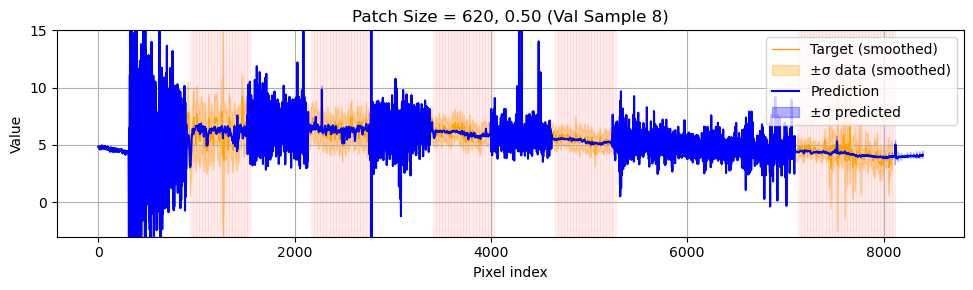

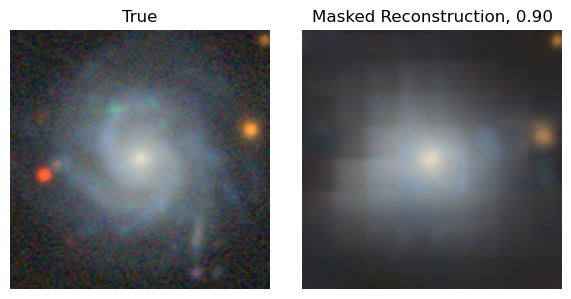

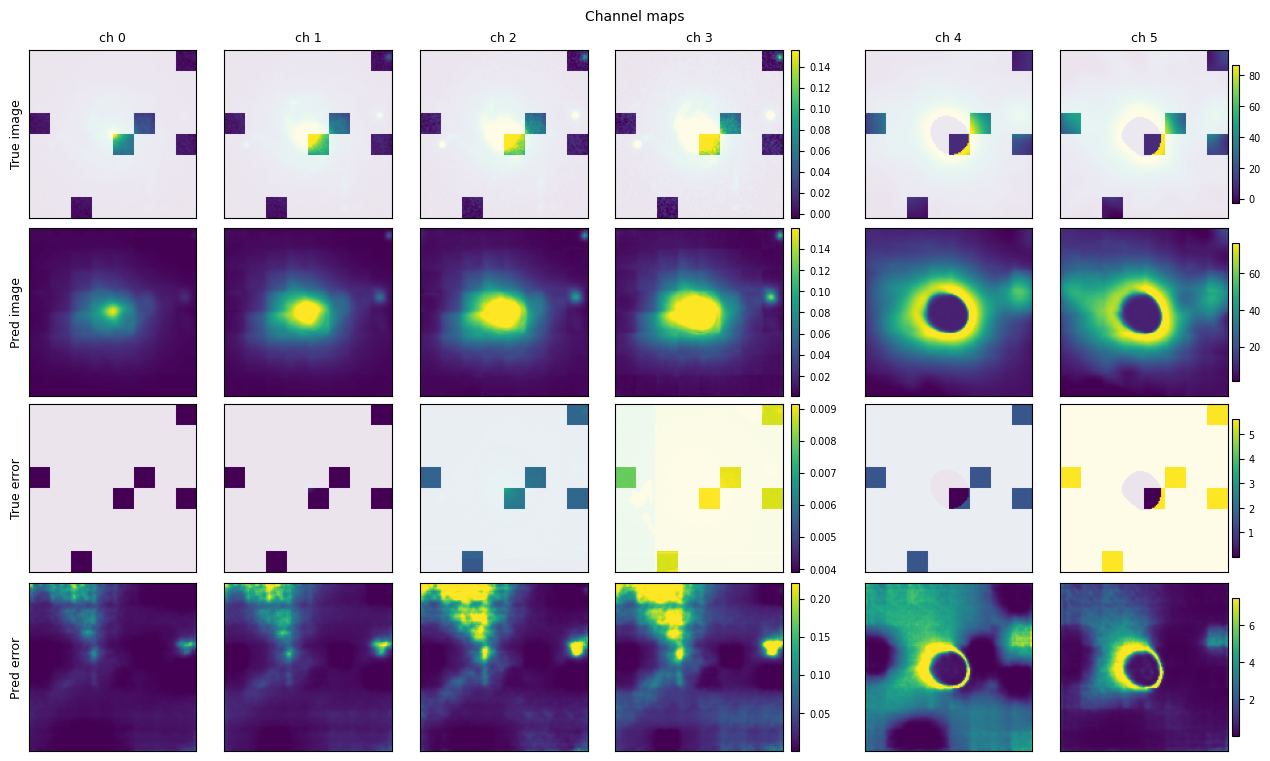

In [11]:
# 4) Visualize with the provided visualize() function.
visualize(
    model,
    spec,
    error,
    spec_pred,
    error_pred,
    img,
    img_error,
    pred_img,
    error_img,
    mask_spec,
    mask_img,
    i = 8
)

In [76]:
xy_pix

tensor([-0.4193,  0.1550])

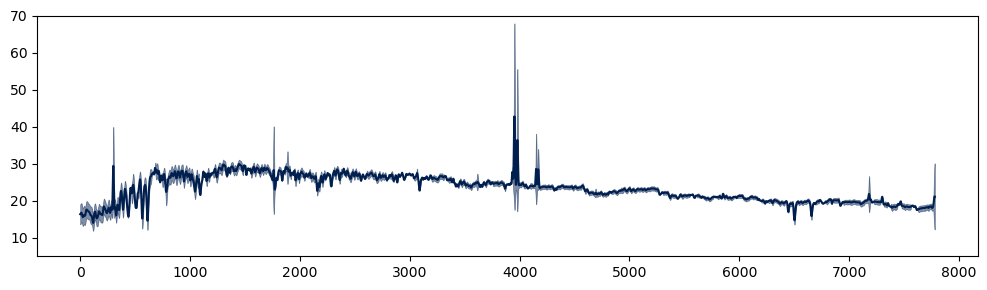

In [66]:
from utils.DataProcessing import get_kernel
kernel = get_kernel(4)
y, e = spec_pred.view(-1).detach().numpy()[310:-310], np.exp(error_pred.view(-1).detach().numpy()[310:-310])
y = smooth_data(y, kernel)
e = smooth_data(e, kernel)
x = np.arange(y.size)
c = "#001F4E"
plt.figure(figsize=(10, 3))
plt.ylim(5, 70)
plt.plot(x, y, color=c, lw=1.5)
plt.fill_between(x, y - e, y + e, color=c, alpha=0.5, linewidth=0.5)
plt.tight_layout()

In [74]:
xy_pix

tensor([-0.4193,  0.1550])

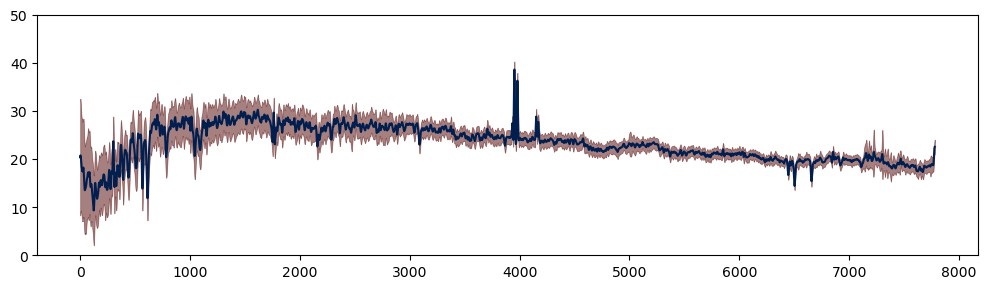

In [73]:
from utils.DataProcessing import get_kernel
kernel = get_kernel(4)
y, e = spec.numpy(), error.numpy()
y = smooth_data(y, kernel)
e = smooth_data(e, kernel)
x = np.arange(y.size)
c = "#001F4E"
r = "#4E0001"
plt.figure(figsize=(10, 3))
plt.ylim(0, 50)
# plt.xlim(0, 100)
plt.plot(x, y, color=c, lw=1.5)
plt.fill_between(x, y - 2 * e, y + 2 * e, color=r, alpha=0.5, linewidth=0.5)
plt.tight_layout()

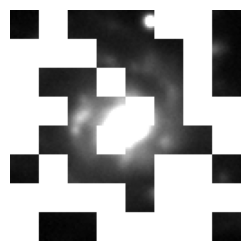

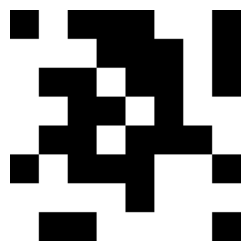

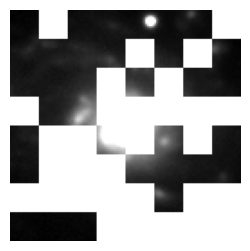

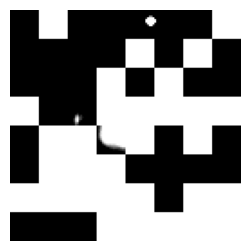

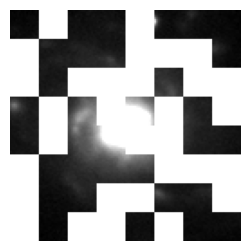

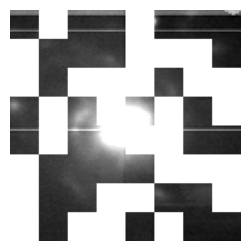

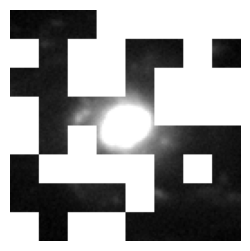

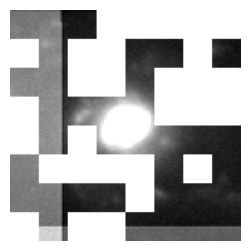

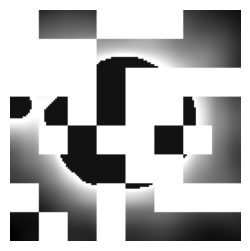

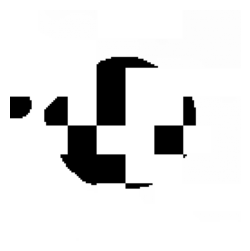

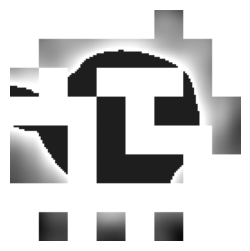

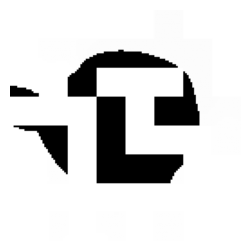

In [20]:
from models.MyTimm import generate_attn_mask

num_channels, img_size, patch_size = 6, 128, 16
grid = img_size // patch_size  # 8
num_patches = num_channels * grid * grid  # 384

# Generate 50% random mask using the model's masking function
token_mask = generate_attn_mask(1, 0.5, num_patches, return_attn_mask=False)
pixel_mask = token_mask.view(num_channels, grid, grid).numpy()
pixel_mask = pixel_mask.repeat(patch_size, axis=1).repeat(patch_size, axis=2)

img_np = img.numpy()
img_err_np = img_error.numpy()

for c in range(num_channels):
    for label, data in [('img', img_np), ('img_err', img_err_np)]:
        chan = data[c]
        vmin, vmax = np.percentile(chan, [0, 97])
        masked = chan.copy()
        masked[pixel_mask[c]] = np.nan
        cmap = plt.cm.gray.copy()
        cmap.set_bad('white')
        fig, ax = plt.subplots(figsize=(3, 3))
        ax.imshow(masked, cmap=cmap, origin='lower', vmin=vmin, vmax=vmax)
        ax.axis('off')
        fig.savefig(f'masked_{label}_ch{c}.png', dpi=200, bbox_inches='tight', pad_inches=0)
        plt.show()

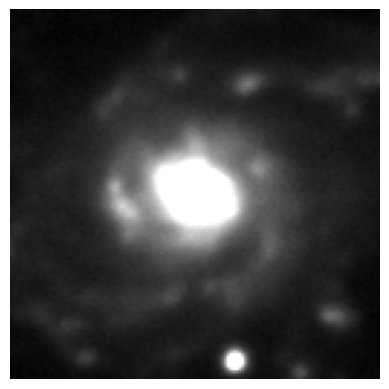

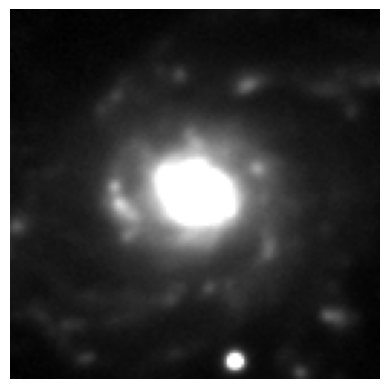

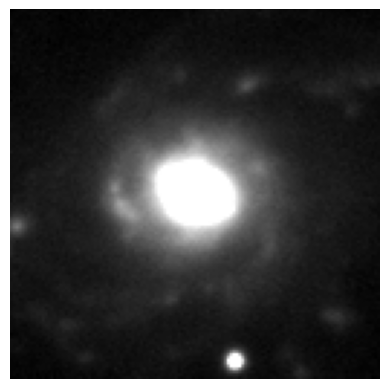

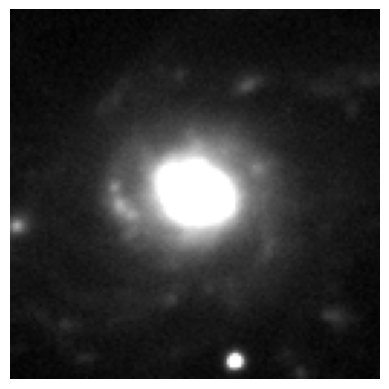

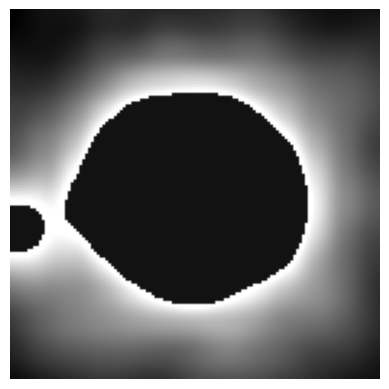

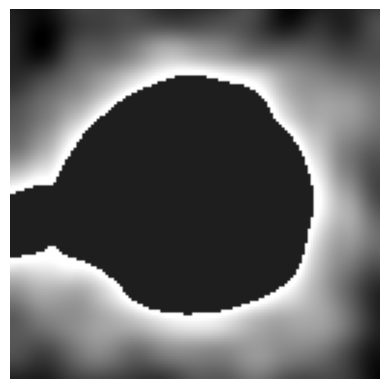

In [17]:
for i in range(6):
    # Set vmin and vmax to be 20th and 80th percentiles of the image for better contrast
    vmin, vmax = np.percentile(img[i], [0, 97])
    plt.imshow(img[i], cmap='gray', vmin=vmin, vmax=vmax)
    plt.axis('off')
    plt.show()